**Environment Setup and Data Loading**

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('biotech_funding.csv')

df['date'] = pd.to_datetime(df['date'])

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   deal_id                1208 non-null   object        
 1   date                   1208 non-null   datetime64[ns]
 2   year                   1208 non-null   int64         
 3   deal_type              1208 non-null   object        
 4   acquirer_or_investors  1208 non-null   object        
 5   target_or_company      1208 non-null   object        
 6   value_usd_bn           1208 non-null   float64       
 7   description            1208 non-null   object        
 8   is_megadeal            1208 non-null   int64         
 9   is_real_headline       1208 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 94.5+ KB
None


,deal_id,date,year,deal_type,acquirer_or_investors,target_or_company,value_usd_bn,description,is_megadeal,is_real_headline
0,D0001,2009-03-09,2009,M&A,Pfizer,Wyeth,68.000,Pfizer-Wyeth megamerger,1,1
1,D0041,2010-01-08,2010,Series_B,F-Prime Capital,Oncgen OS,0.403,Series_B 2010,0,0
2,D0036,2010-01-12,2010,IPO,Public markets,Yothap IO,0.456,IPO 2010,0,0
3,D0045,2010-01-16,2010,M&A,Roche,Aermod AB,1.158,M&A 2010,0,0
4,D0053,2010-01-17,2010,Series_B,Polaris Partners,Tavyot OS,0.643,Series_B 2010,0,0


**Annual Funding Velocity (Line Chart)**

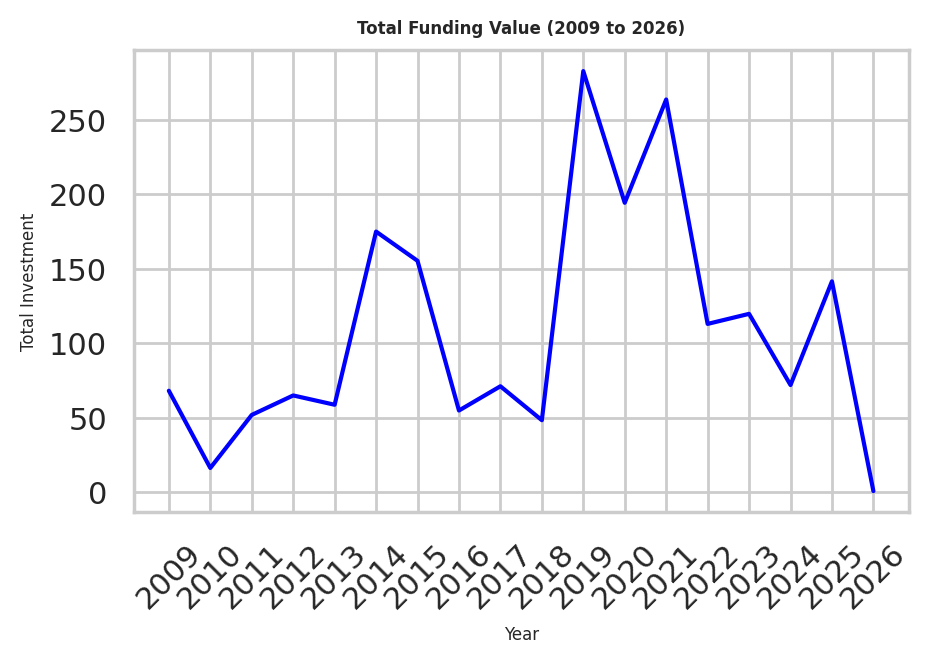

In [20]:
annual_funding = df.groupby('year')['value_usd_bn'].sum().reset_index()

plt.figure(figsize=(5, 3))
sns.lineplot(data=annual_funding, x='year', y='value_usd_bn', color='blue')

plt.title('Total Funding Value (2009 to 2026)', fontsize=6, fontweight='bold')
plt.ylabel('Total Investment', fontsize=6)
plt.xlabel('Year', fontsize=6)
plt.xticks(annual_funding['year'], rotation=45)

plt.savefig('annual_trends.png', bbox_inches='tight')
plt.show()

**Analysis of Deal Composition (Grouped Bar Chart)**

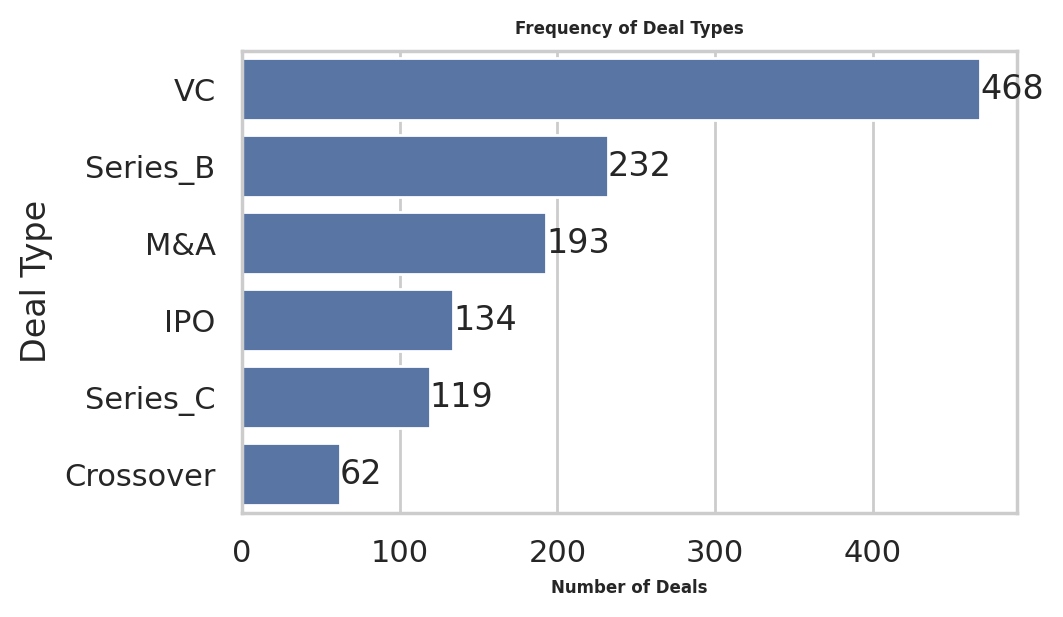

In [27]:
plt.figure(figsize=(5, 3))

deal_counts = df['deal_type'].value_counts().reset_index()
deal_counts.columns = ['Deal Type', 'Count']

ax = sns.barplot(data=deal_counts, x='Count', y='Deal Type')

plt.title('Frequency of Deal Types', fontsize=6, fontweight='bold')
plt.xlabel('Number of Deals', fontsize=6, fontweight='bold')

for i in ax.containers:
    ax.bar_label(i)

plt.savefig('deal_composition.png')
plt.show()

**Investment Concentration by Top Players (Horizontal Bar Chart)**

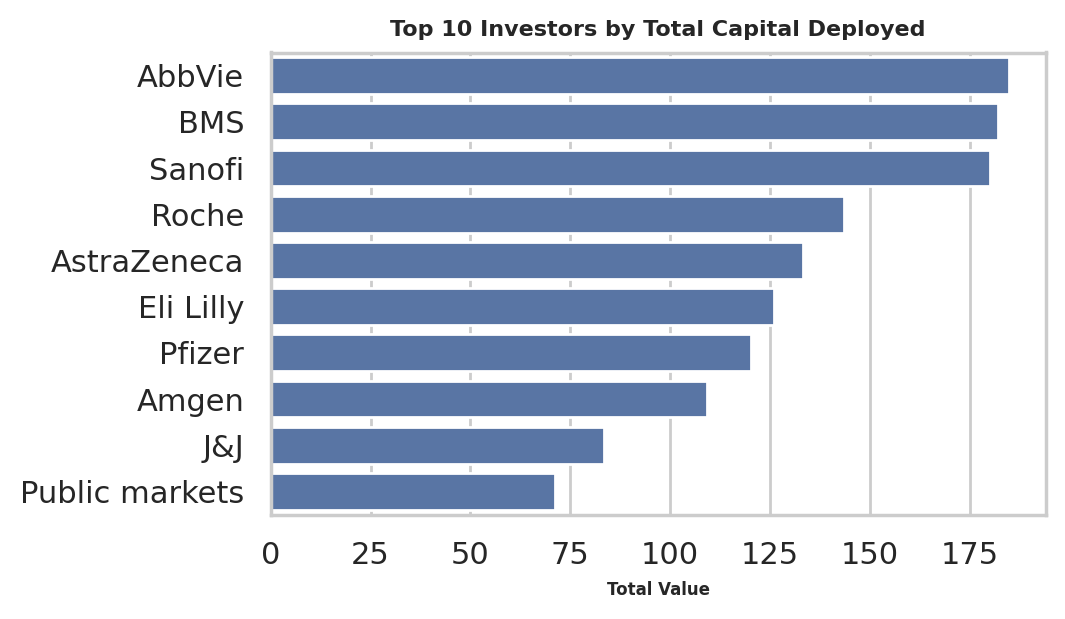

In [34]:
top_investors = df.groupby('acquirer_or_investors')['value_usd_bn'].sum().nlargest(10).reset_index()

plt.figure(figsize=(5, 3))
ax = sns.barplot(data=top_investors, x='value_usd_bn', y='acquirer_or_investors')

plt.title('Top 10 Investors by Total Capital Deployed', fontsize=8, fontweight='bold')
plt.xlabel('Total Value', fontsize=6, fontweight='bold')
plt.ylabel('')

plt.savefig('top_investors.png')
plt.show()

**Capital Distribution and Outlier Detection (Box Plot)**

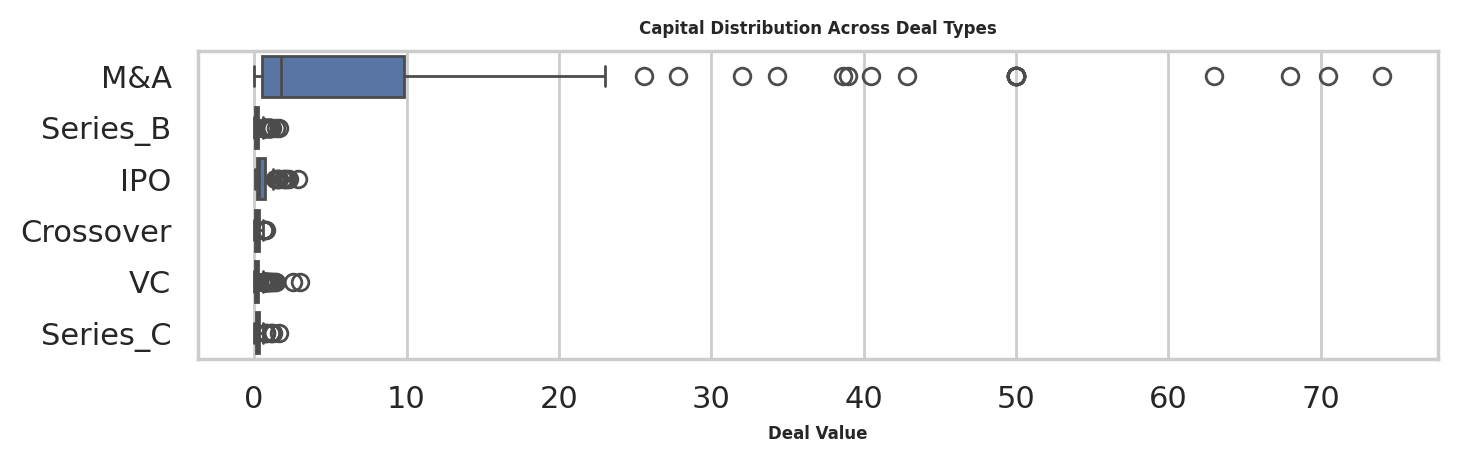

In [43]:
plt.figure(figsize=(8, 2))

sns.boxplot(data=df, x='value_usd_bn', y='deal_type')

plt.title('Capital Distribution Across Deal Types', fontsize=6, fontweight='bold')
plt.xlabel('Deal Value', fontsize=6, fontweight='bold')
plt.ylabel('')

plt.savefig('value_boxplot.png')
plt.show()